In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Import Libraries

In [ ]:
import os
import librosa
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint


## 2. Dataset Path (Data Collection)

In [ ]:
dataset_path = "/content/drive/MyDrive/bangla dataset"


## 3. Audio Processing (Load + Normalize)

In [ ]:
import os

total_audio_files = 0
for emotion in os.listdir(dataset_path):
    emotion_folder = os.path.join(dataset_path, emotion)
    if os.path.isdir(emotion_folder):
        for file_name in os.listdir(emotion_folder):
            if file_name.endswith(".wav"):
                total_audio_files += 1

print(f"Total number of original audio files: {total_audio_files}")

Total number of original audio files: 1115


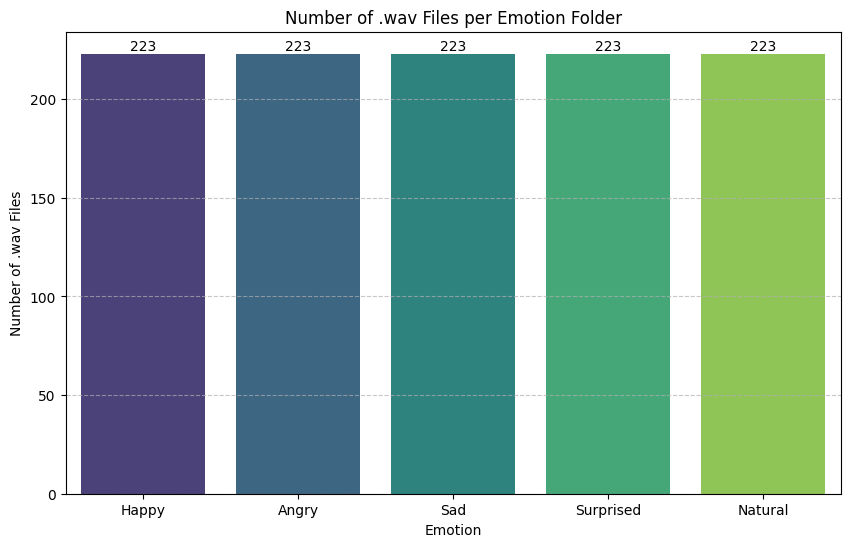

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Assuming dataset_path is already defined and valid from previous cells
dataset_path = "/content/drive/MyDrive/bangla dataset"

emotion_counts = {}
for emotion in os.listdir(dataset_path):
    emotion_folder = os.path.join(dataset_path, emotion)
    if os.path.isdir(emotion_folder):
        wav_count = 0
        for file_name in os.listdir(emotion_folder):
            if file_name.endswith(".wav"):
                wav_count += 1
        emotion_counts[emotion] = wav_count

# Convert to a pandas DataFrame for easier plotting
import pandas as pd
df_counts = pd.DataFrame(list(emotion_counts.items()), columns=['Emotion', 'WAV_File_Count'])

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Emotion', y='WAV_File_Count', data=df_counts, palette='viridis', hue='Emotion', legend=False)
plt.title('Number of .wav Files per Emotion Folder')
plt.xlabel('Emotion')
plt.ylabel('Number of .wav Files')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

In [ ]:
def load_audio(file_path):
    audio, sr = librosa.load(file_path, sr=None)
    audio = librosa.util.normalize(audio)
    return audio, sr


## 4. Segmentation

In [ ]:
def segment_audio(audio, sr, segment_length=3):

    segment_samples = segment_length * sr
    segments = []

    for start in range(0, len(audio), segment_samples):
        end = start + segment_samples
        segment = audio[start:end]

        if len(segment) == segment_samples:
            segments.append(segment)

    return segments


## 5. Feature Extraction (MFCC + Chroma + Spectral Contrast)

In [ ]:
def extract_features(audio, sr):

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)

    features = np.hstack([
        np.mean(mfcc.T, axis=0),
        np.mean(chroma.T, axis=0),
        np.mean(spectral_contrast.T, axis=0)
    ])

    return features


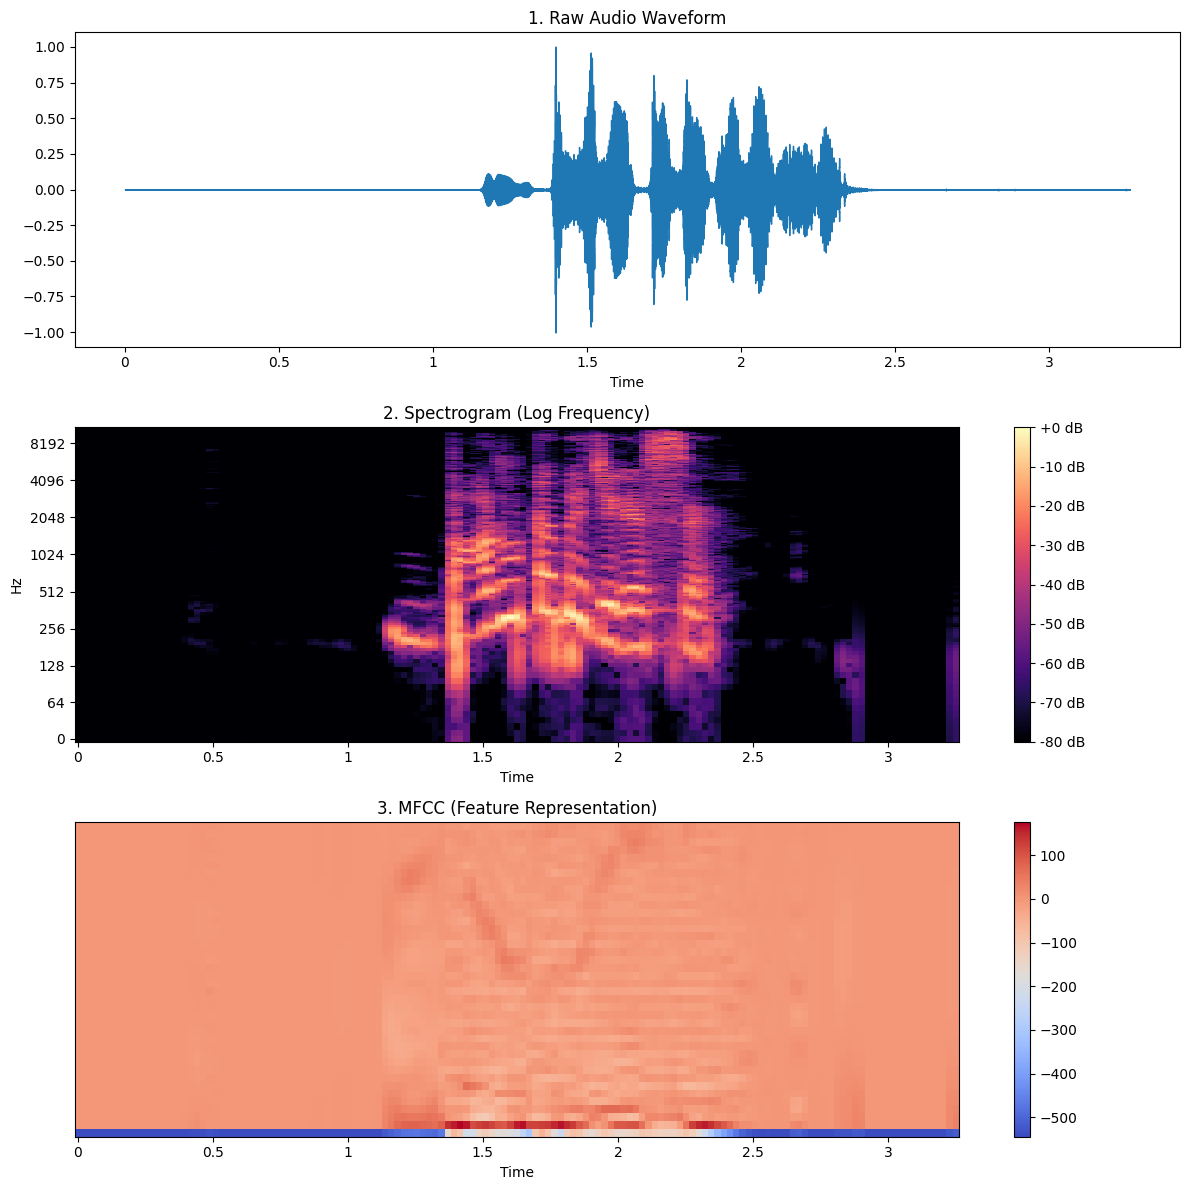

In [ ]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load a sample file
file_path = "/content/drive/MyDrive/emotion data/Angry/03-01-03-02-01-02-08.wav"
audio, sr = librosa.load(file_path)

plt.figure(figsize=(12, 12))

# 1. Waveform
plt.subplot(3, 1, 1)
librosa.display.waveshow(audio, sr=sr)
plt.title('1. Raw Audio Waveform')

# 2. Spectrogram (Log Scale)
plt.subplot(3, 1, 2)
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
librosa.display.specshow(D, y_axis='log', x_axis='time', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('2. Spectrogram (Log Frequency)')

# 3. MFCC
plt.subplot(3, 1, 3)
mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
librosa.display.specshow(mfccs, x_axis='time', sr=sr)
plt.colorbar()
plt.title('3. MFCC (Feature Representation)')

plt.tight_layout()
plt.show()

## 6. Prosodic Features (Pitch, Tempo)

In [ ]:
def prosodic_features(audio, sr):

    pitch, _ = librosa.piptrack(y=audio, sr=sr)
    pitch_mean = np.mean(pitch)

    tempo, _ = librosa.beat.beat_track(y=audio, sr=sr)

    return np.array([pitch_mean, tempo])


## 7. Data Augmentation

In [ ]:
def add_noise(data, noise_factor=0.005):
    noise = np.random.randn(len(data))
    return data + noise_factor * noise

def pitch_shift(data, sr, n_steps=2):
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=n_steps)

def time_stretch(data, rate=1.1):
    return librosa.effects.time_stretch(y=data, rate=rate)


## 8. Load Dataset + Extract Features

In [ ]:
X = []
y = []

for emotion in os.listdir(dataset_path):

    emotion_folder = os.path.join(dataset_path, emotion)

    if not os.path.isdir(emotion_folder):
        continue

    for file in os.listdir(emotion_folder):

        if file.endswith(".wav"):

            file_path = os.path.join(emotion_folder, file)

            audio, sr = load_audio(file_path)

            features = extract_features(audio, sr)

            X.append(features)
            y.append(emotion)

            # Augmentation
            audio_noise = add_noise(audio)
            features_noise = extract_features(audio_noise, sr)
            X.append(features_noise)
            y.append(emotion)

            audio_pitch = pitch_shift(audio, sr)
            features_pitch = extract_features(audio_pitch, sr)
            X.append(features_pitch)
            y.append(emotion)

            audio_stretch = time_stretch(audio)
            features_stretch = extract_features(audio_stretch, sr)
            X.append(features_stretch)
            y.append(emotion)

X = np.array(X)
y = np.array(y)

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)
print("Classes:", np.unique(y))


/tmp/ipykernel_1056/3262836936.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1056/3262836936.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1056/3262836936.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-pa

Feature Shape: (4460, 59)
Label Shape: (4460,)
Classes: ['Angry' 'Happy' 'Natural' 'Sad' 'Surprised']


## 9. Label Encoding

In [ ]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

y_categorical = to_categorical(y_encoded)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Total Data Points:", X.shape[0])
print("Total Classes:", y_categorical.shape[1])

Total Data Points: 4460
Total Classes: 5


## 10. Feature Scaling

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


## 11. Shuffle Dataset

In [ ]:
indices = np.arange(X_scaled.shape[0])
np.random.shuffle(indices)

X_shuffled = X_scaled[indices]
y_shuffled = y_categorical[indices]


## 12. Build Neural Network Model

In [ ]:
model = Sequential([
    Input(shape=(X_shuffled.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_shuffled.shape[1], activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,901 (191.02 KB)

 Trainable params: 48,901 (191.02 KB)

 Non-trainable params: 0 (0.00 B)

## 13. Train Model

In [ ]:
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

history = model.fit(
    X_shuffled,
    y_shuffled,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint]
)


Epoch 1/50
108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3652 - loss: 1.4606
Epoch 1: val_accuracy improved from None to 0.59081, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4339 - loss: 1.3236 - val_accuracy: 0.5908 - val_loss: 1.0352
Epoch 2/50
 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5426 - loss: 1.0933
Epoch 2: val_accuracy improved from 0.59081 to 0.66143, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5712 - loss: 1.0439 - val_accuracy: 0.6614 - val_loss: 0.8710
Epoch 3/50
106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6288 - loss: 0.9052
Epoch 3: val_accuracy improved from 0.66143 to 0.70179, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6328 - loss: 0.9020 - val_accura

## 14. Accuracy Graph

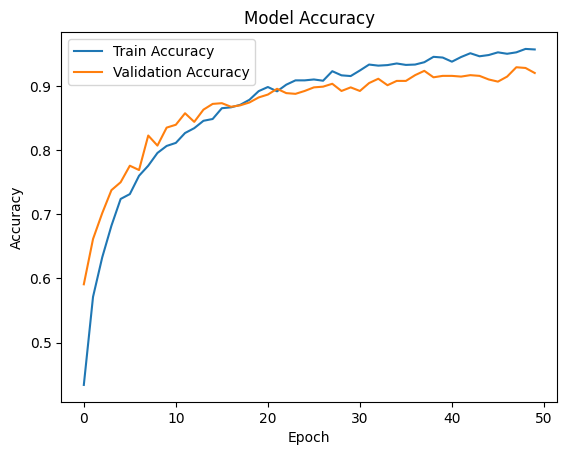

In [ ]:
plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train Accuracy","Validation Accuracy"])

plt.show()


## 15. Loss Graph

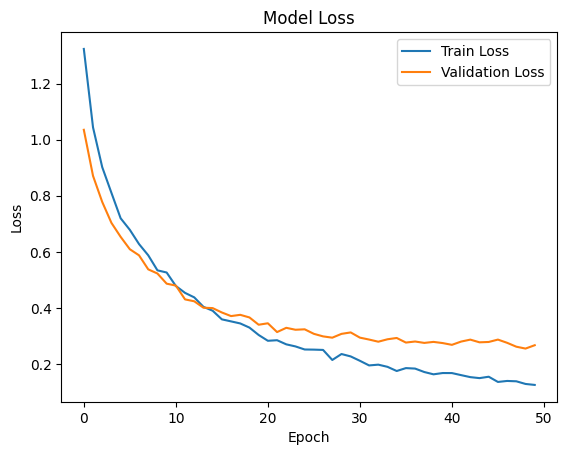

In [ ]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train Loss","Validation Loss"])

plt.show()


## 16. Confusion Matrix

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


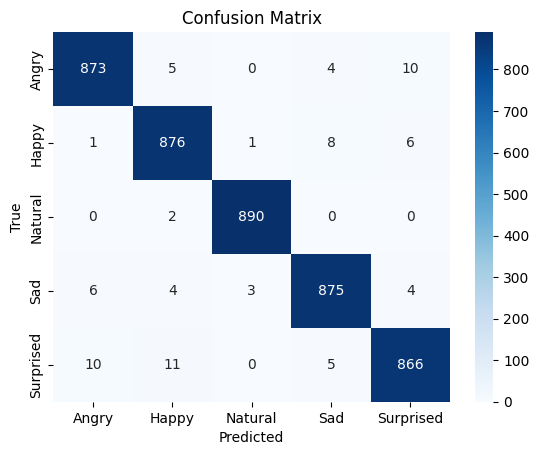

In [ ]:
y_pred = model.predict(X_scaled)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_categorical, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()


## 17. Classification Report

In [ ]:
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=le.classes_
)

print(report)


              precision    recall  f1-score   support

       Angry       0.98      0.98      0.98       892
       Happy       0.98      0.98      0.98       892
     Natural       1.00      1.00      1.00       892
         Sad       0.98      0.98      0.98       892
   Surprised       0.98      0.97      0.97       892

    accuracy                           0.98      4460
   macro avg       0.98      0.98      0.98      4460
weighted avg       0.98      0.98      0.98      4460



## 18. Emotion Prediction Function (Testing)

In [ ]:
def predict_emotion(file_path):

    audio, sr = load_audio(file_path)

    # Extract all features (MFCC, Chroma, Spectral Contrast) using the same function as training
    features = extract_features(audio, sr)

    # Reshape for scaling: scaler expects a 2D array
    features_reshaped = features.reshape(1, -1)

    # Scale the features
    features_scaled = scaler.transform(features_reshaped)

    # Make prediction
    prediction = model.predict(features_scaled)

    # Get predicted label
    predicted_label = le.inverse_transform([np.argmax(prediction)])

    return predicted_label[0]

# To fix the FileNotFoundError, you can either upload a 'test.wav' file
# to /content/ or use an existing file from your dataset for testing.
# Example: using an existing file from the 'Angry' emotion folder
test_file = "/content/test.wav" # Corrected path to where 'test.wav' is located

emotion = predict_emotion(test_file)

print("Predicted Emotion:", emotion)

/tmp/ipykernel_1056/3262836936.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Emotion: Sad
